# Preprocessing

---

## Paso 1: Carga de Datos y Separación de Variables

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Read the data
X = pd.read_csv('train.csv', index_col='id')
X_test_full = pd.read_csv('test.csv', index_col='id')


# Remove rows with missing target, separate target from predictors
X.dropna(axis=0, subset=['Irrigation_Need'], inplace=True)
y = X['Irrigation_Need'].copy()              
X.drop(['Irrigation_Need'], axis=1, inplace=True)

# Break off validation set from training data
X_train_full, X_valid_full, y_train, y_valid = train_test_split(X, y, train_size=0.8, test_size=0.2,
                                                                random_state=0)

# Select categorical columns with relatively low cardinality (convenient but arbitrary)
low_cardinality_cols = [cname for cname in X_train_full.columns if X_train_full[cname].nunique() < 10 and 
                        X_train_full[cname].dtype == "object"]
# Select numeric columns
numeric_cols = [cname for cname in X_train_full.columns if X_train_full[cname].dtype in ['int64', 'float64']]


# Keep selected columns only
my_cols = low_cardinality_cols + numeric_cols
X_train = X_train_full[my_cols].copy()
X_valid = X_valid_full[my_cols].copy()
X_test = X_test_full[my_cols].copy()



## Paso 2: Pipeline de Transformación

Desarrollamos la pipeline para transformar las variables, estándarizar los datos y entrenar un modelo.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

scaler = MinMaxScaler()



categorical_transformer= Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
numerical_transformer = Pipeline(steps=[
    ('normalización', scaler)
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numeric_cols),
        ('cat', categorical_transformer, low_cardinality_cols)])

## Paso 3: Definición del Modelo

Primero, partiré con un modelo simple para probar su desempeño, luego haré pruebas con más modelos de clasificación multiclase para ver si puedo mejorar el rendimiento.

In [ ]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC, LinearSVC

model = OneVsRestClassifier(LinearSVC(random_state=0))

In [ ]:
my_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('model', model)
                             ])

## Paso 4: Entrenamiento y Evaluación

In [ ]:
# Preprocessing of training data, fit model 
my_pipeline.fit(X_train, y_train)


# Preprocessing of validation data, get predictions
preds=my_pipeline.predict(X_valid)


# Evaluate the model
from sklearn.metrics import classification_report
print(classification_report(y_valid, preds))


# Modelado

---

## Paso 5: Comparación de Estrategias (OvR vs Softmax)

Comparamos **One-vs-Rest** (`LinearSVC`) contra **Softmax** (`LogisticRegression` con `multinomial`) para ver cuál generaliza mejor.

In [ ]:
from sklearn.linear_model import LogisticRegression

models = {
    'OvR (LinearSVC)': OneVsRestClassifier(LinearSVC(random_state=0)),
    'Softmax (LogisticRegression)': LogisticRegression(
        solver='lbfgs', max_iter=1000, random_state=0
    ),
}

results = {}
for name, m in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', m)
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_valid)
    report = classification_report(y_valid, preds, output_dict=True)
    results[name] = {
        'accuracy': report['accuracy'],
        'macro_f1': report['macro avg']['f1-score'],
        'weighted_f1': report['weighted avg']['f1-score'],
    }
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_valid, preds))

In [ ]:
pd.DataFrame(results).T.sort_values('macro_f1', ascending=False)

## Paso 6: Optimización de Hiperparámetros

Usamos `RandomizedSearchCV` para buscar los mejores hiperparámetros del modelo ganador. Es más eficiente que `GridSearchCV` cuando el espacio de búsqueda es grande.

*El mejor modelo fue LogisticRegression o Softmax.*

### Logistic Regresion (softmax)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV
import numpy as np
tuning_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(solver='lbfgs', random_state=0))
])

# Espacio de búsqueda — los parámetros del modelo se acceden con "model__parametro"
param_distributions = {
    'model__C': np.logspace(-3, 3, 20),           # regularización
    'model__max_iter': [500, 1000, 2000,5000,10000],
}


#Usamos RandomizedSearchCV para buscar los mejores hiperparámetros del modelo ganador
search = GridSearchCV(
    tuning_pipeline,
    param_distributions,
    cv=10,
    scoring='balanced_accuracy', # Usamos balanced accuracy para evaluar el rendimiento en todas las clases,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train, y_train)

### XGBClassifier

In [13]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
import numpy as np


# Codificar las etiquetas a valores numéricos (XGBoost lo requiere)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_valid_encoded = le.transform(y_valid)


tuning_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
    device='cuda',
    n_estimators=300,
    random_state=0,
))
])

# Espacio de búsqueda — los parámetros del modelo se acceden con "model__parametro"
param_distributions = {
    'model__learning_rate': np.logspace(-3, 0, 20),           # tasa de aprendizaje
    'model__max_depth': [3, 5, 7, 9, 11],                     # profundidad máxima del árbol
    'model__n_estimators': [100, 200, 300, 400, 500],        # número de árboles
}


#Usamos RandomizedSearchCV para buscar los mejores hiperparámetros
search = RandomizedSearchCV(
    tuning_pipeline,
    param_distributions,
    n_iter=50,  # 50 combinaciones aleatorias (de 500 posibles)
    cv=3,
    scoring='balanced_accuracy',
    n_jobs=1,  # n_jobs=1 para que XGBoost use la GPU correctamente
    verbose=1,
    random_state=0,
)

search.fit(X_train, y_train_encoded)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


c:\Users\fabra\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:751: UserWarning: [22:35:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__learning_rate': array([0.001 ..., 1. ]), 'model__max_depth': [3, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used her

In [22]:
xgb_clasifier_predicts = le.inverse_transform(search.predict(X_valid))


  XGBClassifier
              precision    recall  f1-score   support

        High       0.96      0.92      0.94      4183
         Low       0.99      0.99      0.99     73926
      Medium       0.98      0.97      0.98     47891

    accuracy                           0.98    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.98      0.98      0.98    126000



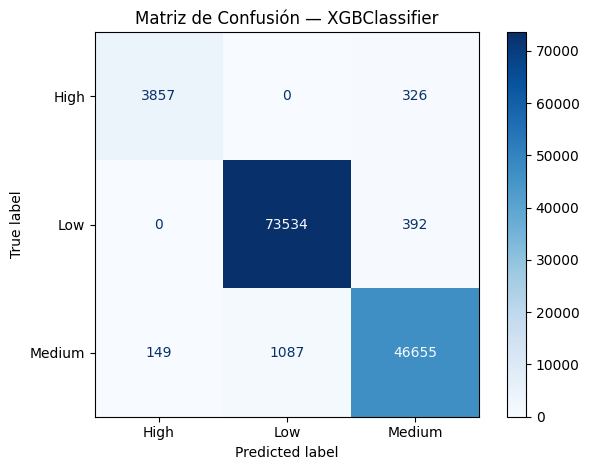

In [ ]:
report = classification_report(y_valid, xgb_clasifier_predicts, output_dict=True)
resultados = {
        'accuracy': report['accuracy'],
        'macro_f1': report['macro avg']['f1-score'],
        'weighted_f1': report['weighted avg']['f1-score'],
    }
print(f"\n{'='*50}")
print(f"  XGBClassifier")
print(f"{'='*50}")
print(classification_report(y_valid, xgb_clasifier_predicts))

# Matriz de confusión en porcentaje
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_valid, xgb_clasifier_predicts)
cm_pct = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100
labels = sorted(y_valid.unique())
disp = ConfusionMatrixDisplay(confusion_matrix=cm_pct, display_labels=labels)
disp.plot(cmap=plt.cm.Blues, values_format='.1f')
plt.title("Matriz de Confusión (%) — XGBClassifier")
plt.tight_layout()
plt.show()

## Paso 7: Exportar Predicciones

Generamos el archivo `submission.csv` con el formato requerido por la competencia para subirlo a Kaggle.

In [32]:
# Predecir sobre el set de test
test_preds = le.inverse_transform(search.predict(X_test))

# Crear DataFrame con el formato de submission
submission = pd.DataFrame({
    'id': X_test.index,
    'Irrigation_Need': test_preds
})

submission.to_csv('submission.csv', index=False)
print(f"Submission guardada: {submission.shape[0]} filas")
submission.head(10)

Submission guardada: 270000 filas


,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low
5,630005,Medium
6,630006,Low
7,630007,Medium
8,630008,High
9,630009,Low
